In [1]:
# Install required libraries
!pip install prophet scikit-learn xgboost plotly folium statsmodels --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Stats & ML
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# Time series
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet

# Map
import folium
from folium.plugins import HeatMap

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
# ---- OPTION A: Upload directly in Colab ----
from google.colab import files
uploaded = files.upload()   # Click and select your CSV file

import io
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# ---- OPTION B: Mount Google Drive (comment out Option A above) ----
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/GlobalWeatherRepository.csv')

print(f'✅ Dataset loaded! Shape: {df.shape}')
df.head()

Saving GlobalWeatherRepository.csv to GlobalWeatherRepository.csv
✅ Dataset loaded! Shape: (146760, 41)


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


## 🧹 Step 3: Data Cleaning & Preprocessing

In [4]:
# Basic info
print('=== Dataset Info ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print(f'\nColumn names:\n{df.columns.tolist()}')

=== Dataset Info ===
Rows: 146760, Columns: 41

Column names:
['country', 'location_name', 'latitude', 'longitude', 'timezone', 'last_updated_epoch', 'last_updated', 'temperature_celsius', 'temperature_fahrenheit', 'condition_text', 'wind_mph', 'wind_kph', 'wind_degree', 'wind_direction', 'pressure_mb', 'pressure_in', 'precip_mm', 'precip_in', 'humidity', 'cloud', 'feels_like_celsius', 'feels_like_fahrenheit', 'visibility_km', 'visibility_miles', 'uv_index', 'gust_mph', 'gust_kph', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index', 'sunrise', 'sunset', 'moonrise', 'moonset', 'moon_phase', 'moon_illumination']


In [5]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print('=== Missing Values ===')
print(missing_df if not missing_df.empty else 'No missing values!')

# Visualize missing values
if not missing_df.empty:
    fig, ax = plt.subplots(figsize=(10, 4))
    missing_df['Missing %'].plot(kind='bar', ax=ax, color='coral')
    ax.set_title('Missing Values by Column (%)')
    ax.set_ylabel('Missing %')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

=== Missing Values ===
No missing values!


In [6]:
# Parse datetime
df['last_updated'] = pd.to_datetime(df['last_updated'])
df['date'] = df['last_updated'].dt.date
df['year'] = df['last_updated'].dt.year
df['month'] = df['last_updated'].dt.month
df['day'] = df['last_updated'].dt.day

# Fill numeric missing with median
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing with mode
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print('✅ Missing values handled!')
print(f'Remaining missing: {df.isnull().sum().sum()}')

✅ Missing values handled!
Remaining missing: 0


In [7]:
# Outlier detection using IQR for temperature
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

original_len = len(df)

# Identify the temperature column (handles different naming)
temp_col = [c for c in df.columns if 'temp_c' in c.lower() or 'temperature' in c.lower()]
print(f'Temperature columns found: {temp_col}')

temp_col = temp_col[0] if temp_col else None
if temp_col:
    df = remove_outliers_iqr(df, temp_col)
    print(f'Removed {original_len - len(df)} outlier rows based on {temp_col}')
else:
    print('No temperature column found — skipping outlier removal')

df = df.reset_index(drop=True)
print(f'Clean dataset shape: {df.shape}')

Temperature columns found: ['temperature_celsius', 'temperature_fahrenheit']
Removed 2459 outlier rows based on temperature_celsius
Clean dataset shape: (144301, 45)


In [8]:
# Normalize numeric columns
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[num_cols] = scaler.fit_transform(df[num_cols])
print('✅ Data normalized (StandardScaler). df_scaled ready for ML models.')

✅ Data normalized (StandardScaler). df_scaled ready for ML models.


## 📊 Step 4: Exploratory Data Analysis (EDA)

In [9]:
# Basic statistics
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
latitude,144301.0,18.717188,-41.3,3.75,16.7833,40.1811,65.3,24.279146
longitude,144301.0,21.703868,-175.2,-6.8361,21.4333,49.8822,179.22,65.995364
last_updated_epoch,144301.0,1748357587.393712,1715849100.0,1732005900.0,1748336400.0,1764400500.0,1781158500.0,18865200.722519
last_updated,144301,2025-05-27 17:02:03.554237440,2024-05-16 01:45:00,2024-11-19 09:45:00,2025-05-27 11:00:00,2025-11-29 08:00:00,2026-06-11 19:00:00,NaN
temperature_celsius,144301.0,21.743689,-2.0,16.2,24.0,28.0,45.8,8.830802
temperature_fahrenheit,144301.0,71.140429,28.3,61.2,75.2,82.4,114.4,15.895335
wind_mph,144301.0,7.976505,2.2,3.8,6.7,11.0,1841.2,7.101264
wind_kph,144301.0,12.840676,3.6,6.1,10.8,17.6,2963.2,11.425027
wind_degree,144301.0,168.902135,1.0,80.0,161.0,255.0,360.0,103.469555
pressure_mb,144301.0,1013.967242,947.0,1010.0,1013.0,1018.0,3006.0,10.03809


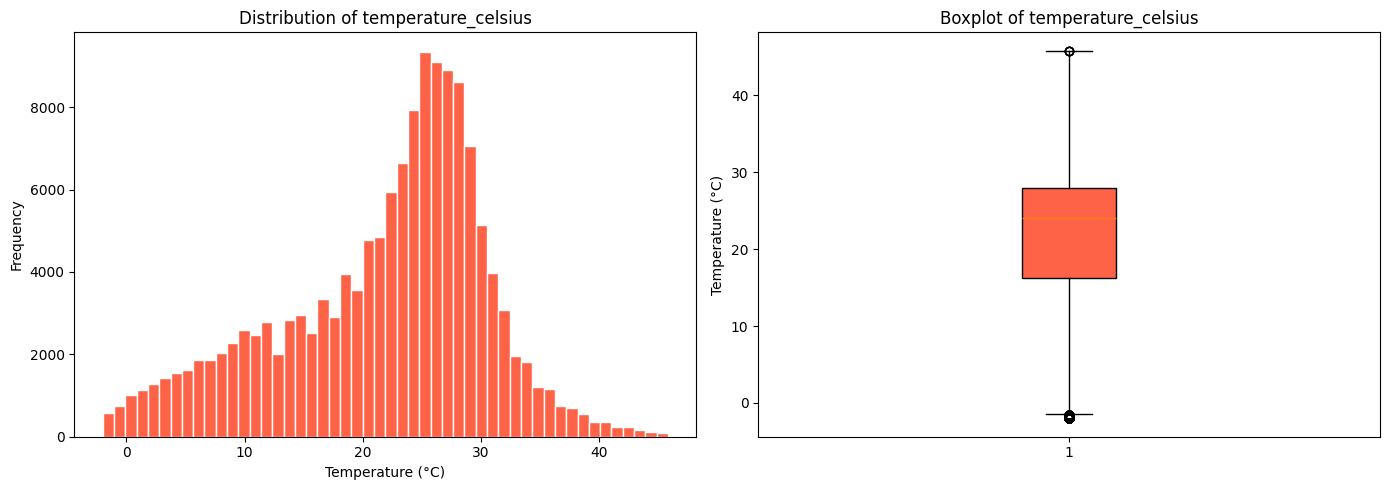

In [10]:
# Temperature distribution
if temp_col:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(df[temp_col], bins=50, color='tomato', edgecolor='white')
    axes[0].set_title(f'Distribution of {temp_col}')
    axes[0].set_xlabel('Temperature (°C)')
    axes[0].set_ylabel('Frequency')

    axes[1].boxplot(df[temp_col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='tomato', color='black'))
    axes[1].set_title(f'Boxplot of {temp_col}')
    axes[1].set_ylabel('Temperature (°C)')

    plt.tight_layout()
    plt.show()

Precipitation columns: ['precip_mm', 'precip_in']
Humidity columns: ['humidity']


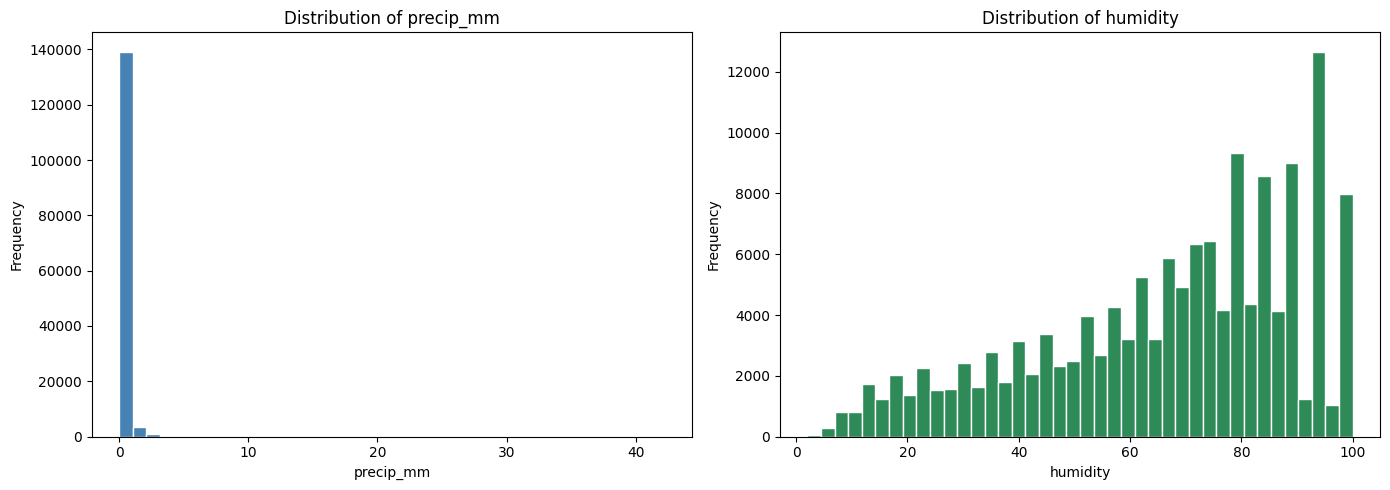

In [11]:
# Precipitation / Humidity analysis
precip_col = [c for c in df.columns if 'precip' in c.lower()]
humidity_col = [c for c in df.columns if 'humidity' in c.lower()]

print(f'Precipitation columns: {precip_col}')
print(f'Humidity columns: {humidity_col}')

plot_cols = precip_col[:1] + humidity_col[:1]
if plot_cols:
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(7*len(plot_cols), 5))
    if len(plot_cols) == 1:
        axes = [axes]
    colors = ['steelblue', 'seagreen']
    for ax, col, color in zip(axes, plot_cols, colors):
        ax.hist(df[col].dropna(), bins=40, color=color, edgecolor='white')
        ax.set_title(f'Distribution of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
    plt.tight_layout()
    plt.show()

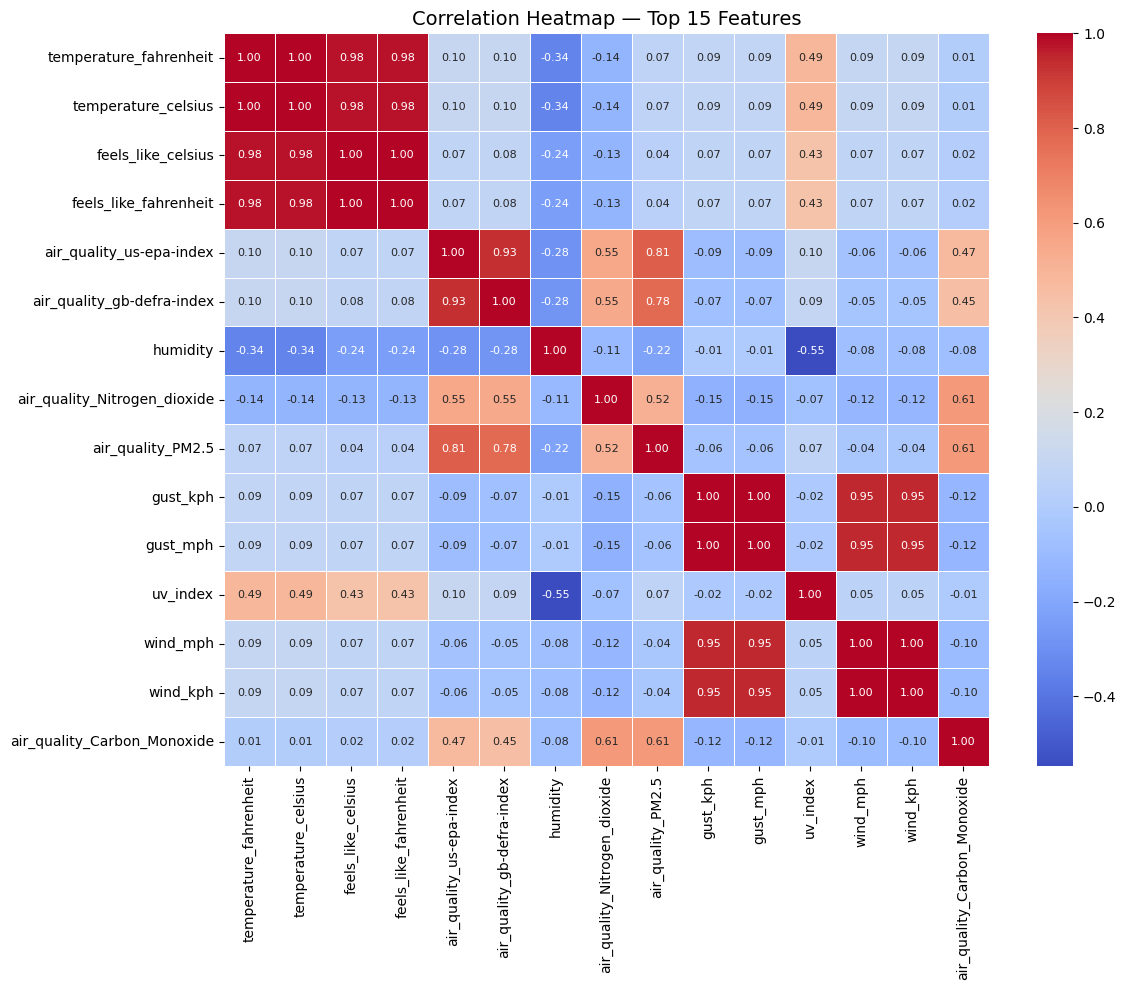

In [12]:
# Correlation heatmap (top numeric features)
top_cols = df[num_cols].corr().abs().sum().sort_values(ascending=False).head(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df[top_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 15 Features', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
# Monthly temperature trend
if temp_col:
    monthly_avg = df.groupby('month')[temp_col].mean().reset_index()
    fig = px.line(monthly_avg, x='month', y=temp_col,
                  title='Average Temperature by Month',
                  markers=True, color_discrete_sequence=['tomato'])
    fig.update_layout(xaxis_title='Month', yaxis_title='Avg Temperature (°C)')
    fig.show()

Country column: ['country']


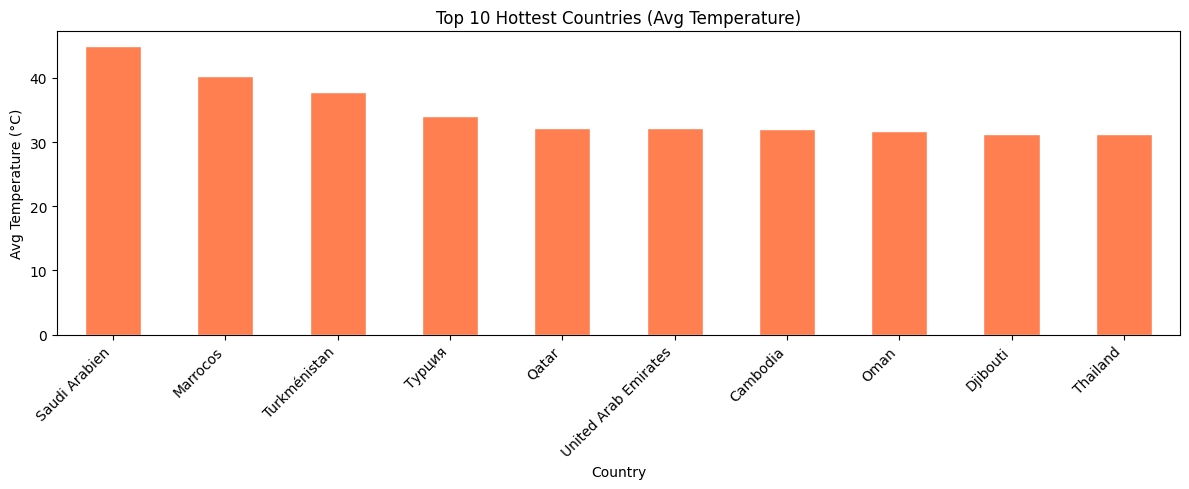

In [14]:
# Top 10 countries by average temperature
country_col = [c for c in df.columns if 'country' in c.lower()]
print(f'Country column: {country_col}')

if country_col and temp_col:
    country_col = country_col[0]
    top_countries = df.groupby(country_col)[temp_col].mean().sort_values(ascending=False).head(10)
    fig, ax = plt.subplots(figsize=(12, 5))
    top_countries.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
    ax.set_title('Top 10 Hottest Countries (Avg Temperature)')
    ax.set_ylabel('Avg Temperature (°C)')
    ax.set_xlabel('Country')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 🚨 Step 5: Anomaly Detection

In [15]:
# Use Isolation Forest on numeric features
features_for_anomaly = df[num_cols].dropna()

iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_labels = iso_forest.fit_predict(features_for_anomaly)

df_anomaly = df.loc[features_for_anomaly.index].copy()
df_anomaly['anomaly'] = anomaly_labels  # -1 = anomaly, 1 = normal

n_anomalies = (df_anomaly['anomaly'] == -1).sum()
print(f'Total anomalies detected: {n_anomalies} ({n_anomalies/len(df_anomaly)*100:.1f}%)')

Total anomalies detected: 7215 (5.0%)


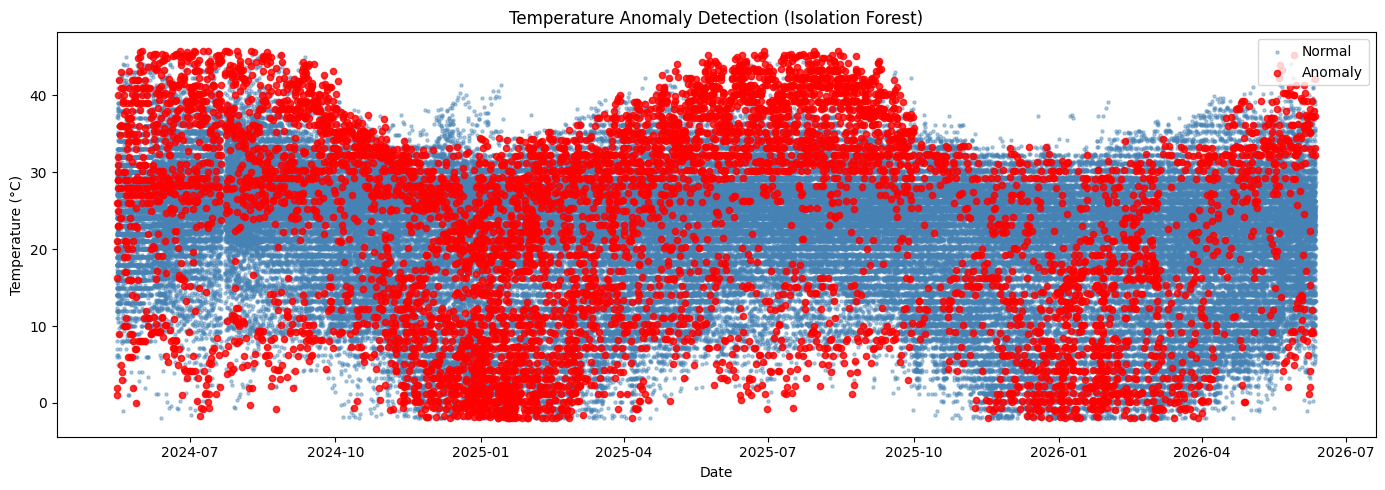

In [16]:
# Visualize anomalies on temperature timeline
if temp_col:
    normal = df_anomaly[df_anomaly['anomaly'] == 1]
    anomalies = df_anomaly[df_anomaly['anomaly'] == -1]

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(normal['last_updated'], normal[temp_col],
               c='steelblue', s=5, alpha=0.4, label='Normal')
    ax.scatter(anomalies['last_updated'], anomalies[temp_col],
               c='red', s=20, alpha=0.8, label='Anomaly')
    ax.set_title('Temperature Anomaly Detection (Isolation Forest)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Temperature (°C)')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 🔮 Step 6: Time Series Forecasting

In [17]:
# Prepare time series: daily average temperature globally
if temp_col:
    ts = df.groupby('date')[temp_col].mean().reset_index()
    ts.columns = ['date', 'avg_temp']
    ts['date'] = pd.to_datetime(ts['date'])
    ts = ts.sort_values('date').reset_index(drop=True)
    print(f'Time series points: {len(ts)}')
    print(ts.tail())

Time series points: 756
          date   avg_temp
751 2026-06-07  22.493846
752 2026-06-08  22.821134
753 2026-06-09  22.682564
754 2026-06-10  22.644103
755 2026-06-11  22.563918


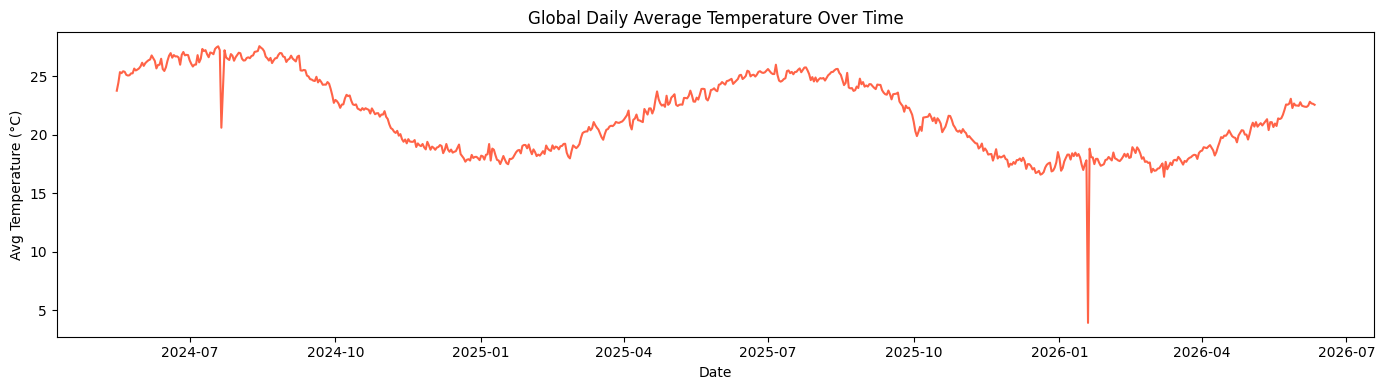

In [18]:
# Plot raw time series
if temp_col:
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(ts['date'], ts['avg_temp'], color='tomato', linewidth=1.5)
    ax.set_title('Global Daily Average Temperature Over Time')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Temperature (°C)')
    plt.tight_layout()
    plt.show()

In [19]:
# ADF Test for stationarity
if temp_col:
    result = adfuller(ts['avg_temp'].dropna())
    print('=== ADF Stationarity Test ===')
    print(f'ADF Statistic: {result[0]:.4f}')

    print(f'p-value: {result[1]:.4f}')
    print('Series is', 'STATIONARY ✅' if result[1] < 0.05 else 'NON-STATIONARY ⚠️')

=== ADF Stationarity Test ===
ADF Statistic: -1.3984
p-value: 0.5830
Series is NON-STATIONARY ⚠️


### 6a. ARIMA Model

ARIMA — MAE: 1.5763 | RMSE: 2.3601 | R²: -0.1954


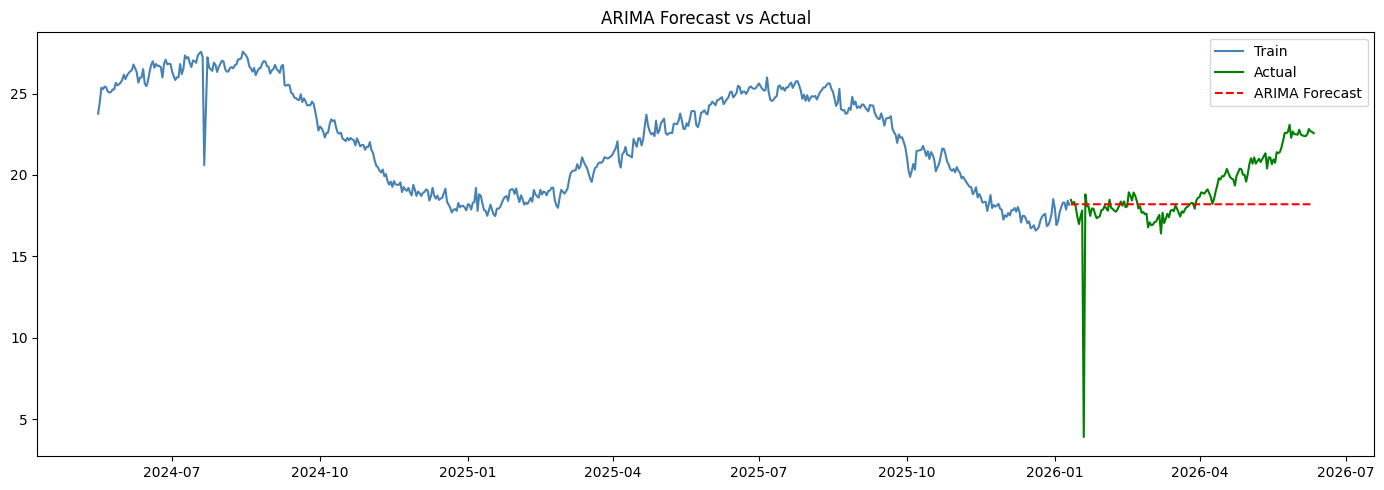

In [20]:
if temp_col and len(ts) >= 30:
    split = int(len(ts) * 0.8)
    train_ts = ts['avg_temp'][:split]
    test_ts = ts['avg_temp'][split:]

    # Fit ARIMA
    arima_model = ARIMA(train_ts, order=(5, 1, 0))
    arima_fit = arima_model.fit()

    # Forecast
    arima_forecast = arima_fit.forecast(steps=len(test_ts))

    # Metrics
    arima_mae = mean_absolute_error(test_ts, arima_forecast)
    arima_rmse = np.sqrt(mean_squared_error(test_ts, arima_forecast))
    arima_r2 = r2_score(test_ts, arima_forecast)

    print(f'ARIMA — MAE: {arima_mae:.4f} | RMSE: {arima_rmse:.4f} | R²: {arima_r2:.4f}')

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(ts['date'][:split], train_ts, label='Train', color='steelblue')
    ax.plot(ts['date'][split:], test_ts.values, label='Actual', color='green')
    ax.plot(ts['date'][split:], arima_forecast.values, label='ARIMA Forecast', color='red', linestyle='--')
    ax.set_title('ARIMA Forecast vs Actual')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Not enough data for ARIMA — need at least 30 time points')

### 6b. Prophet Model

Prophet — MAE: 2.0716 | RMSE: 2.5376 | R²: -0.3819


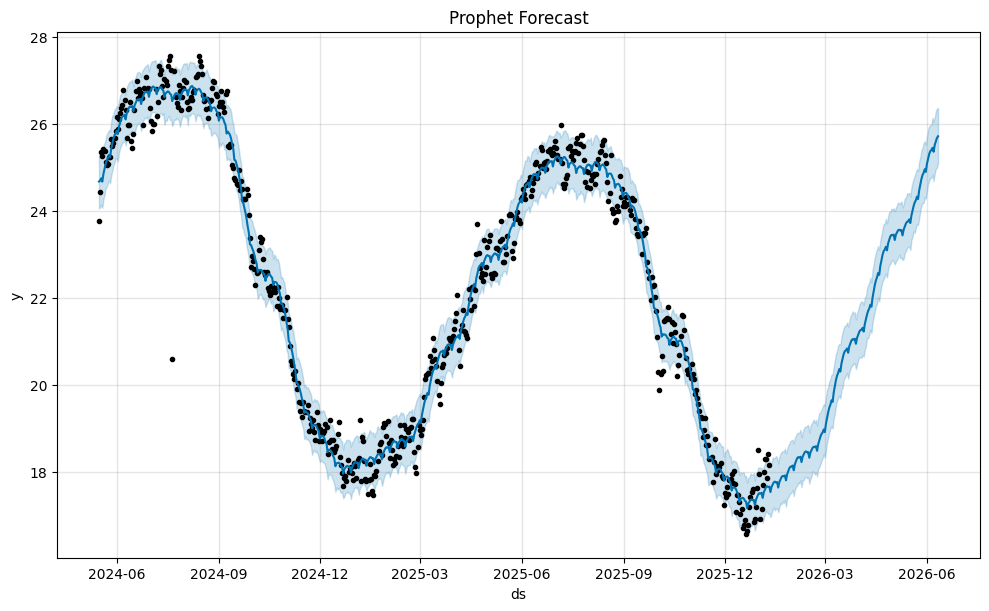

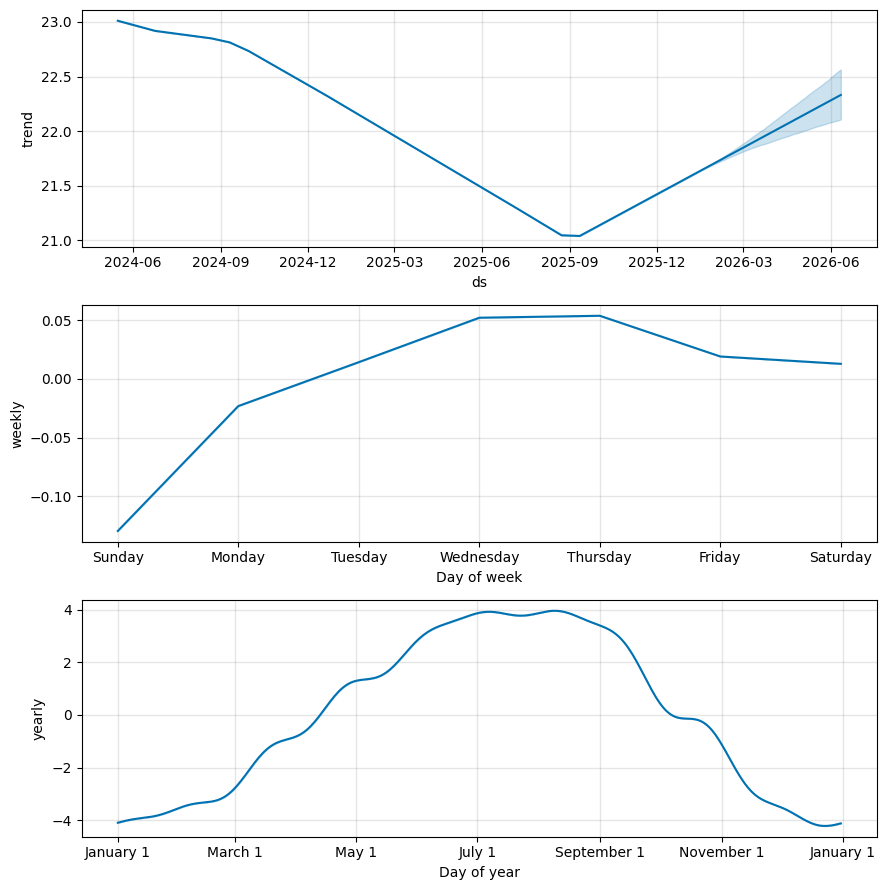

In [21]:
if temp_col and len(ts) >= 30:
    prophet_df = ts[['date', 'avg_temp']].rename(columns={'date': 'ds', 'avg_temp': 'y'})

    split = int(len(prophet_df) * 0.8)
    train_p = prophet_df[:split]
    test_p = prophet_df[split:]

    prophet_model = Prophet(daily_seasonality=False, yearly_seasonality=True)
    prophet_model.fit(train_p)

    future = prophet_model.make_future_dataframe(periods=len(test_p))
    forecast = prophet_model.predict(future)

    prophet_pred = forecast[['ds', 'yhat']].tail(len(test_p))['yhat'].values

    p_mae = mean_absolute_error(test_p['y'], prophet_pred)
    p_rmse = np.sqrt(mean_squared_error(test_p['y'], prophet_pred))
    p_r2 = r2_score(test_p['y'], prophet_pred)

    print(f'Prophet — MAE: {p_mae:.4f} | RMSE: {p_rmse:.4f} | R²: {p_r2:.4f}')

    # Prophet built-in plot
    fig = prophet_model.plot(forecast)
    plt.title('Prophet Forecast')
    plt.show()

    fig2 = prophet_model.plot_components(forecast)
    plt.show()

### 6c. XGBoost Model

XGBoost — MAE: 0.4139 | RMSE: 1.2258 | R²: 0.6811


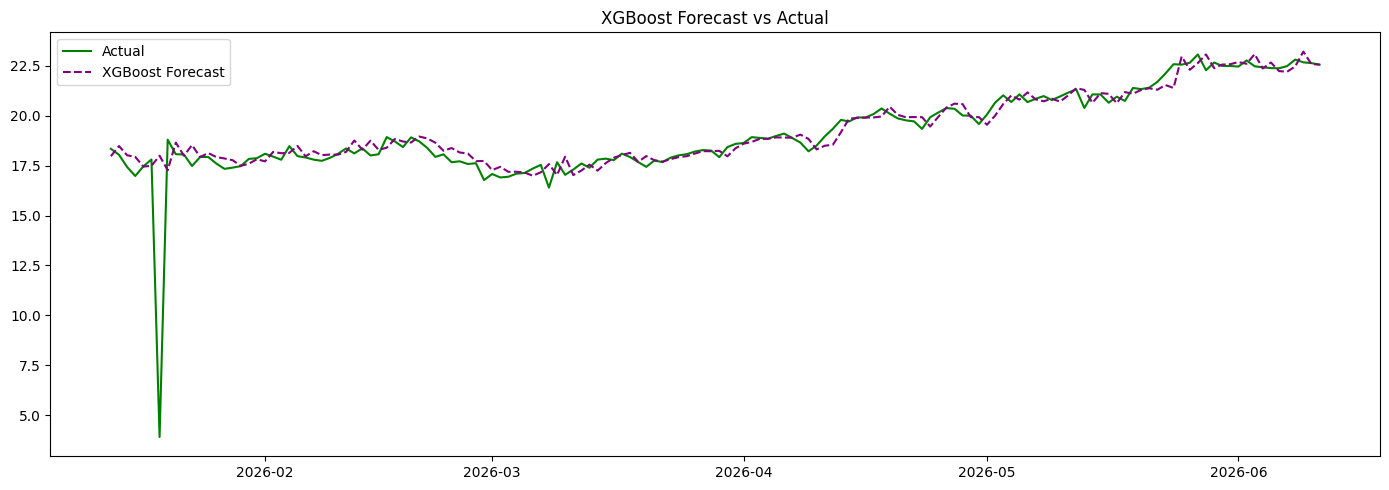

In [22]:
if temp_col and len(ts) >= 30:
    # Feature engineering for XGBoost
    xgb_df = ts.copy()
    xgb_df['dayofyear'] = xgb_df['date'].dt.dayofyear
    xgb_df['month'] = xgb_df['date'].dt.month
    xgb_df['weekday'] = xgb_df['date'].dt.weekday
    # Lag features
    for lag in [1, 3, 7]:
        xgb_df[f'lag_{lag}'] = xgb_df['avg_temp'].shift(lag)
    xgb_df = xgb_df.dropna()

    feature_cols = ['dayofyear', 'month', 'weekday', 'lag_1', 'lag_3', 'lag_7']
    X = xgb_df[feature_cols]
    y = xgb_df['avg_temp']

    split = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
    xgb_r2 = r2_score(y_test, xgb_pred)

    print(f'XGBoost — MAE: {xgb_mae:.4f} | RMSE: {xgb_rmse:.4f} | R²: {xgb_r2:.4f}')

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(xgb_df['date'].values[split:], y_test.values, label='Actual', color='green')
    ax.plot(xgb_df['date'].values[split:], xgb_pred, label='XGBoost Forecast', color='purple', linestyle='--')
    ax.set_title('XGBoost Forecast vs Actual')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 6d. Ensemble Model (Average of ARIMA + Prophet + XGBoost)

Ensemble — MAE: 0.6548 | RMSE: 1.3554 | R²: 0.5972

=== Model Comparison ===
   Model      MAE     RMSE        R²
   ARIMA 1.576336 2.360085 -0.195354
 Prophet 2.071599 2.537588 -0.381921
 XGBoost 0.413895 1.225814  0.681134
Ensemble 0.654763 1.355389  0.597217


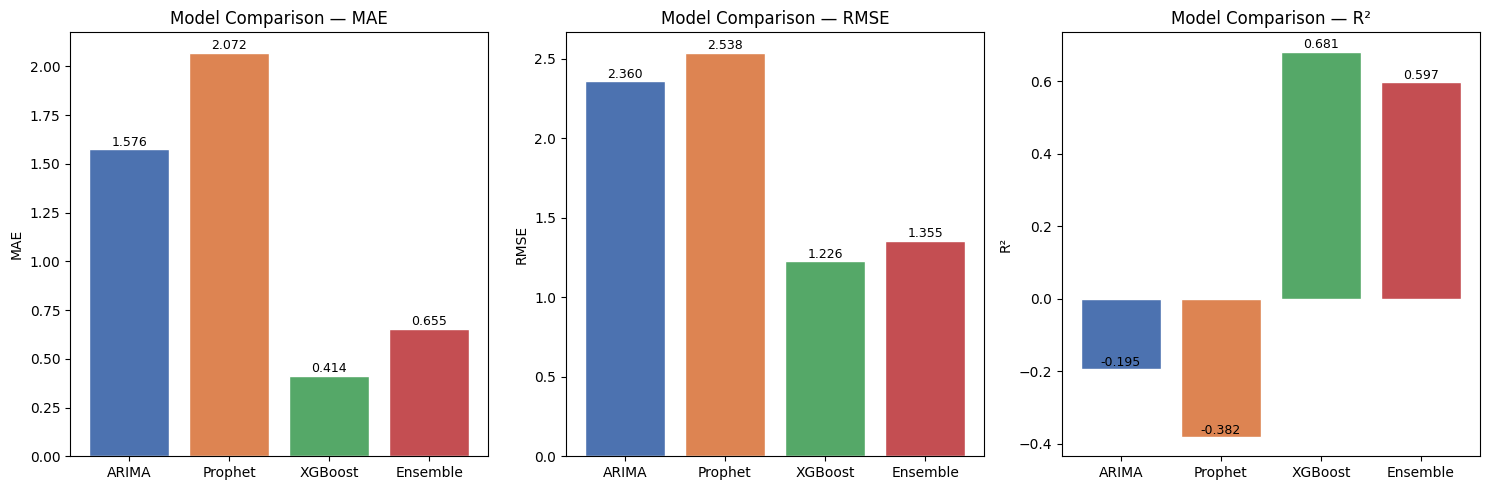

In [23]:
if temp_col and len(ts) >= 30:
    # Align predictions (use the smallest common test length)
    min_len = min(len(arima_forecast), len(prophet_pred), len(xgb_pred))

    ensemble_pred = (
        np.array(arima_forecast.values[:min_len]) +
        np.array(prophet_pred[:min_len]) +
        np.array(xgb_pred[:min_len])
    ) / 3

    actual_vals = test_ts.values[:min_len]

    ens_mae = mean_absolute_error(actual_vals, ensemble_pred)
    ens_rmse = np.sqrt(mean_squared_error(actual_vals, ensemble_pred))
    ens_r2 = r2_score(actual_vals, ensemble_pred)

    print(f'Ensemble — MAE: {ens_mae:.4f} | RMSE: {ens_rmse:.4f} | R²: {ens_r2:.4f}')

    # Model comparison table
    results = pd.DataFrame({
        'Model': ['ARIMA', 'Prophet', 'XGBoost', 'Ensemble'],
        'MAE': [arima_mae, p_mae, xgb_mae, ens_mae],
        'RMSE': [arima_rmse, p_rmse, xgb_rmse, ens_rmse],
        'R²': [arima_r2, p_r2, xgb_r2, ens_r2]
    })
    print('\n=== Model Comparison ===')
    print(results.to_string(index=False))

    # Bar chart comparison
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, metric in zip(axes, ['MAE', 'RMSE', 'R²']):
        colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
        bars = ax.bar(results['Model'], results[metric], color=colors, edgecolor='white')
        ax.set_title(f'Model Comparison — {metric}')
        ax.set_ylabel(metric)
        for bar, val in zip(bars, results[metric]):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()

## 🌟 Step 7: Feature Importance

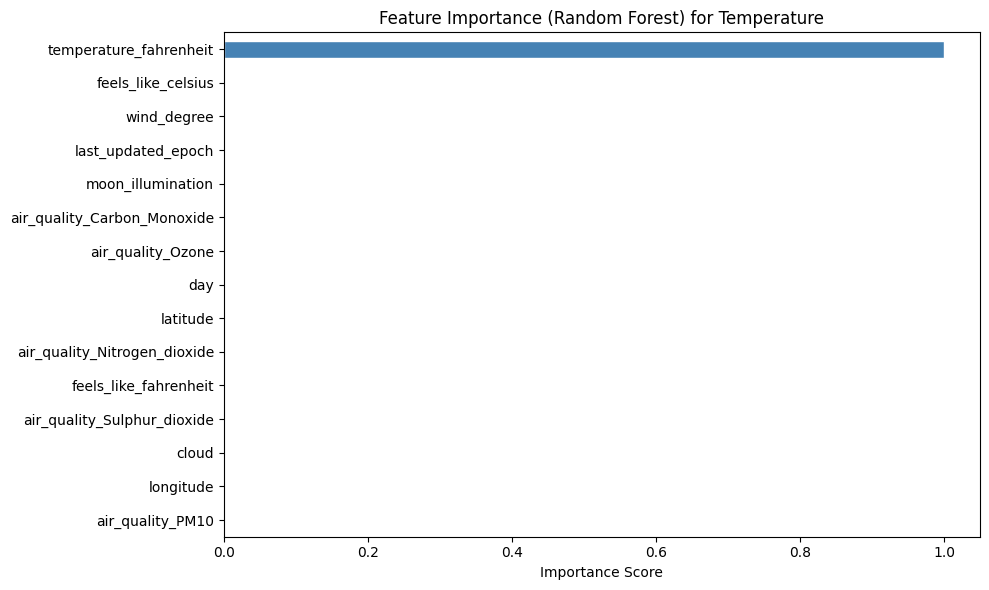

In [24]:
if temp_col:
    # Random Forest for feature importance
    feat_df = df[num_cols].dropna()
    X_feat = feat_df.drop(columns=[temp_col], errors='ignore')
    y_feat = feat_df[temp_col]

    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_feat, y_feat)

    importance = pd.Series(rf.feature_importances_, index=X_feat.columns)
    importance = importance.sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title('Feature Importance (Random Forest) for Temperature')
    ax.set_xlabel('Importance Score')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

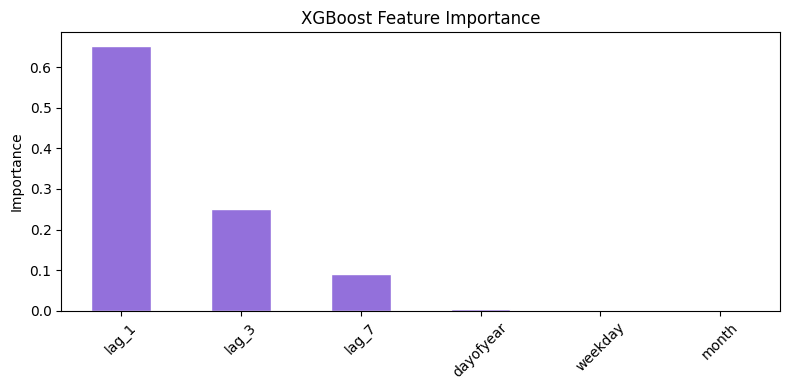

In [25]:
if temp_col and len(ts) >= 30:
    # XGBoost feature importance
    xgb_importance = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    xgb_importance.plot(kind='bar', ax=ax, color='mediumpurple', edgecolor='white')
    ax.set_title('XGBoost Feature Importance')
    ax.set_ylabel('Importance')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 🌍 Step 8: Spatial / Geographical Analysis

In [26]:
# Check for lat/lon columns
lat_col = [c for c in df.columns if 'lat' in c.lower()]
lon_col = [c for c in df.columns if 'lon' in c.lower()]

print(f'Lat columns: {lat_col}')
print(f'Lon columns: {lon_col}')

Lat columns: ['latitude']
Lon columns: ['longitude']


In [27]:
if lat_col and lon_col and temp_col:
    lat_col = lat_col[0]
    lon_col = lon_col[0]

    # Plotly interactive globe map
    map_df = df[[lat_col, lon_col, temp_col]].dropna().sample(min(2000, len(df)))

    fig = px.scatter_geo(
        map_df, lat=lat_col, lon=lon_col,
        color=temp_col, size_max=8,
        color_continuous_scale='RdYlBu_r',
        title='Global Temperature Distribution',
        projection='natural earth'
    )
    fig.show()

In [28]:
# Folium Heatmap
if lat_col and lon_col and temp_col:
    heat_data = df[[lat_col, lon_col, temp_col]].dropna().sample(min(1000, len(df)))
    heat_data = heat_data.values.tolist()

    m = folium.Map(location=[20, 0], zoom_start=2, tiles='CartoDB positron')
    HeatMap(heat_data, radius=8, blur=10).add_to(m)
    m.save('temperature_heatmap.html')
    print('✅ Heatmap saved as temperature_heatmap.html')
    m  # Display inline in Colab

✅ Heatmap saved as temperature_heatmap.html


## 🌫️ Step 9: Air Quality & Environmental Impact

In [29]:
# Look for air quality columns
aq_cols = [c for c in df.columns if any(x in c.lower() for x in ['air', 'pm2', 'pm10', 'co', 'no2', 'ozone', 'aqi', 'quality'])]
print(f'Air quality columns: {aq_cols}')

Air quality columns: ['country', 'condition_text', 'air_quality_Carbon_Monoxide', 'air_quality_Ozone', 'air_quality_Nitrogen_dioxide', 'air_quality_Sulphur_dioxide', 'air_quality_PM2.5', 'air_quality_PM10', 'air_quality_us-epa-index', 'air_quality_gb-defra-index']


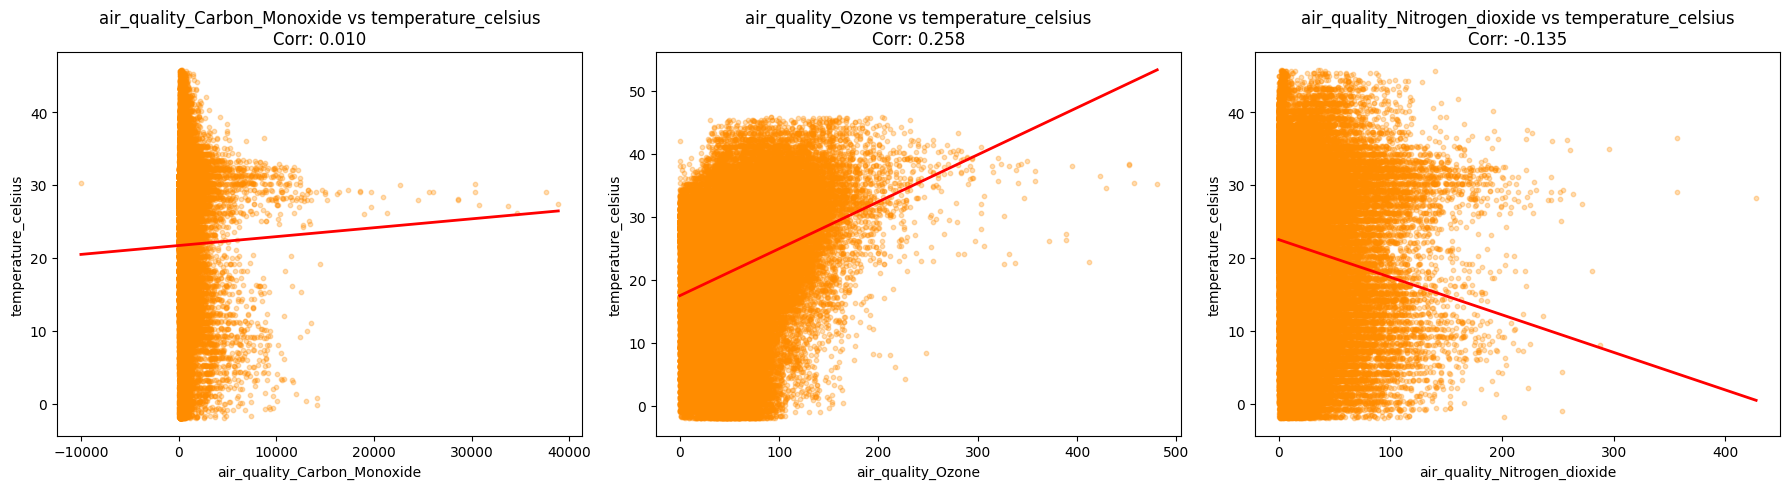

In [32]:
if aq_cols and temp_col:
    # Filter aq_cols to include only numeric columns for plotting
    numeric_aq_cols = [col for col in aq_cols if pd.api.types.is_numeric_dtype(df[col])]

    if not numeric_aq_cols:
        print("No numeric air quality columns found for plotting after filtering.")
    else:
        aq_df = df[numeric_aq_cols + [temp_col]].dropna()

        # Determine how many subplots to create, max 3
        plot_columns_to_show = numeric_aq_cols[:3]

        if not plot_columns_to_show:
            print("No numeric air quality columns available to plot after filtering.")
        else:
            fig, axes = plt.subplots(1, len(plot_columns_to_show), figsize=(6*len(plot_columns_to_show), 5))
            if len(plot_columns_to_show) == 1:
                axes = [axes] # Ensure axes is iterable for single subplot case

            for ax, col in zip(axes, plot_columns_to_show):
                ax.scatter(aq_df[col], aq_df[temp_col], alpha=0.3, s=10, color='darkorange')

                # Perform linear regression if enough data
                x_data = aq_df[col].dropna()
                y_data = aq_df[temp_col].dropna()

                if len(x_data) > 1 and len(y_data) > 1: # np.polyfit requires at least 2 points
                    z = np.polyfit(x_data, y_data, 1)
                    p = np.poly1d(z)
                    x_line = np.linspace(x_data.min(), x_data.max(), 100)
                    ax.plot(x_line, p(x_line), color='red', linewidth=2)
                    corr = aq_df[[col, temp_col]].corr().iloc[0, 1]
                    ax.set_title(f'{col} vs {temp_col}\nCorr: {corr:.3f}')
                else:
                    ax.set_title(f'{col} vs {temp_col}\n(Not enough data for regression)')

                ax.set_xlabel(col)
                ax.set_ylabel(temp_col)

            plt.tight_layout()
            plt.show()
elif not aq_cols:
    print('No explicit air quality columns found. Checking numeric cols for AQ proxies...')
    # Show correlation of all numeric cols with temperature
    if temp_col:
        corr_with_temp = df[num_cols].corr()[temp_col].drop(temp_col).sort_values(key=abs, ascending=False).head(10)
        print('\nTop 10 features correlated with temperature:')
        print(corr_with_temp)

## 🌡️ Step 10: Climate Pattern Analysis

In [31]:
# Seasonal patterns
if temp_col:
    month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

    season_df = df.groupby('month')[temp_col].agg(['mean','std']).reset_index()
    season_df['month_name'] = season_df['month'].map(month_names)

    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=season_df['month_name'], y=season_df['mean'],
        error_y=dict(type='data', array=season_df['std']),
        marker_color='tomato', name='Avg Temp'
    ))
    fig.update_layout(title='Monthly Temperature Pattern (Mean ± Std)',
                      xaxis_title='Month', yaxis_title='Temperature (°C)')
    fig.show()

In [33]:
# Country-wise climate comparison (box plots)
if country_col and temp_col:
    top_n = df[country_col].value_counts().head(8).index
    filtered = df[df[country_col].isin(top_n)]

    fig = px.box(filtered, x=country_col, y=temp_col,
                 color=country_col,
                 title='Temperature Distribution by Top Countries',
                 labels={temp_col: 'Temperature (°C)', country_col: 'Country'})
    fig.update_layout(showlegend=False)
    fig.show()

## 📋 Step 11: Final Summary

In [34]:
print('='*60)
print('      GLOBAL WEATHER TREND FORECASTING — SUMMARY')
print('='*60)
print(f'Dataset Shape: {df.shape}')
print(f'Date Range: {df["last_updated"].min()} to {df["last_updated"].max()}')
print()
if temp_col:
    print(f'Target: {temp_col}')
    print(f'  Mean: {df[temp_col].mean():.2f}°C')
    print(f'  Min:  {df[temp_col].min():.2f}°C')
    print(f'  Max:  {df[temp_col].max():.2f}°C')
    print()
print('Models Built: ARIMA, Prophet, XGBoost, Ensemble')
if temp_col and len(ts) >= 30:
    print()
    print('Model Performance:')
    print(results.to_string(index=False))
print()
print('Analyses Completed:')
print('  ✅ Data Cleaning & Preprocessing')
print('  ✅ EDA (Temperature, Precipitation, Correlations)')
print('  ✅ Anomaly Detection (Isolation Forest)')
print('  ✅ Time Series Forecasting (ARIMA, Prophet, XGBoost, Ensemble)')
print('  ✅ Feature Importance (Random Forest + XGBoost)')
print('  ✅ Spatial/Geographical Analysis')
print('  ✅ Air Quality & Environmental Correlation')
print('  ✅ Climate Pattern & Seasonal Analysis')
print('='*60)

      GLOBAL WEATHER TREND FORECASTING — SUMMARY
Dataset Shape: (144301, 45)
Date Range: 2024-05-16 01:45:00 to 2026-06-11 19:00:00

Target: temperature_celsius
  Mean: 21.74°C
  Min:  -2.00°C
  Max:  45.80°C

Models Built: ARIMA, Prophet, XGBoost, Ensemble

Model Performance:
   Model      MAE     RMSE        R²
   ARIMA 1.576336 2.360085 -0.195354
 Prophet 2.071599 2.537588 -0.381921
 XGBoost 0.413895 1.225814  0.681134
Ensemble 0.654763 1.355389  0.597217

Analyses Completed:
  ✅ Data Cleaning & Preprocessing
  ✅ EDA (Temperature, Precipitation, Correlations)
  ✅ Anomaly Detection (Isolation Forest)
  ✅ Time Series Forecasting (ARIMA, Prophet, XGBoost, Ensemble)
  ✅ Feature Importance (Random Forest + XGBoost)
  ✅ Spatial/Geographical Analysis
  ✅ Air Quality & Environmental Correlation
  ✅ Climate Pattern & Seasonal Analysis
